# Cell 1 — Import & thiết lập

In [39]:
# Xử lý dữ liệu
import pandas as pd
import numpy as np

# FP-Growth & Association Rules
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị bảng đầy đủ
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Cell 2 — Load dữ liệu từ project

In [40]:
# Load basket boolean matrix đã xử lý sẵn (sparse hoặc đầy đủ)
basket = pd.read_parquet('../data/processed/basket_bool.parquet')

# Load dữ liệu hóa đơn gốc để tính trọng số
df_clean = pd.read_csv('../data/processed/cleaned_uk_data.csv')

# Xem thử vài dòng
basket.head(), df_clean.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4356\1512759344.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv('../data/processed/cleaned_uk_data.csv')


(    4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
 0                           False                           False   
 1                           False                           False   
 2                           False                           False   
 3                           False                           False   
 4                           False                           False   
 
     DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK   NINE DRAWER OFFICE TIDY  \
 0               False                         False                     False   
 1               False                         False                     False   
 2               False                         False                     False   
 3               False                         False                     False   
 4               False                         False                     False   
 
     OVAL WALL MIRROR DIAMANTE    RED SPOT GIFT BAG LARGE  \
 0                     

# Cell 3 — Lọc sản phẩm ít xuất hiện & chuyển sang sparse

In [41]:
# Lọc các sản phẩm xuất hiện ít nhất 5 hóa đơn
min_count = 5
product_counts = df_clean.groupby('StockCode')['InvoiceNo'].nunique()
products_keep = product_counts[product_counts >= min_count].index

# Chuyển StockCode sang str để đồng bộ với cột basket
basket.columns = basket.columns.astype(str)
products_keep = products_keep.astype(str)

# Chỉ giữ các cột thực sự có trong basket
products_keep_filtered = [p for p in products_keep if p in basket.columns]

# Lọc basket
basket_filtered = basket[products_keep_filtered]

# Chuyển sang SparseDataFrame boolean để tiết kiệm bộ nhớ
basket_sparse = basket_filtered.astype(pd.SparseDtype(bool, fill_value=False))

# Thông tin ma trận sparse
print(f"Ban đầu có {len(products_keep)} sản phẩm, lọc còn {len(products_keep_filtered)} sản phẩm")
basket_sparse.info()
basket_sparse.head()

Ban đầu có 3463 sản phẩm, lọc còn 0 sản phẩm
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18021 entries, 0 to 18020
Empty DataFrame


""
0
1
2
3
4


# Cell 4 — Hàm mining FP-Growth

In [42]:
def mine_rules_fp(df_onehot, min_support, min_confidence, min_lift):
    """
    Tìm tập phổ biến bằng FP-Growth và sinh association rules
    """
    freq_items = fpgrowth(df_onehot, min_support=min_support, use_colnames=True)
    rules = association_rules(freq_items, metric="confidence", min_threshold=min_confidence)
    rules = rules[rules['lift'] >= min_lift]
    return rules

# Cell 5 — Hàm tính weighted metrics

In [43]:
def weighted_metrics(rules, original_df):
    """
    Tính weighted_support và weighted_lift dựa trên Quantity*Price
    """
    original_df['invoice_weight'] = original_df['Quantity'] * original_df['Price']
    invoice_weight = original_df.groupby('InvoiceNo')['invoice_weight'].sum()

    weighted_support=[]
    for _, r in rules.iterrows():
        items = list(r['antecedents']) + list(r['consequents'])
        inv_with_items = original_df[original_df['StockCode'].isin(items)]['InvoiceNo'].unique()
        ws = invoice_weight.loc[inv_with_items].sum() / invoice_weight.sum()
        weighted_support.append(ws)

    rules['weighted_support'] = weighted_support
    rules['weighted_lift'] = rules['weighted_support'] / (rules['antecedent_support'] * rules['consequent_support'])
    return rules

# Cell 6 — Thử nhiều tham số (unweighted)

In [44]:
# Loại bỏ các hóa đơn trống (không có item nào)
basket_sparse_nonempty = basket_sparse[basket_sparse.sum(axis=1) > 0]

params=[]
min_support_list = [0.01, 0.02, 0.03]  # giảm min_support để tránh empty DF
min_confidence_list = [0.3, 0.5, 0.7]
min_lift_list = [1.0, 1.5, 2.0]

for s in min_support_list:
    for c in min_confidence_list:
        for l in min_lift_list:
            # Mining FP-Growth
            try:
                rules = mine_rules_fp(basket_sparse_nonempty, s, c, l)
                
                # Nếu không có tập phổ biến, gán num_rules=0
                num_rules = len(rules) if not rules.empty else 0
            except Exception as e:
                print(f"Warning: min_s={s}, min_c={c}, min_l={l} --> {e}")
                num_rules = 0

            params.append({'min_s': s, 'min_c': c, 'min_l': l, 'num_rules': num_rules})

df_params = pd.DataFrame(params)
df_params

,min_s,min_c,min_l,num_rules
0,0.01,0.3,1.0,0
1,0.01,0.3,1.5,0
2,0.01,0.3,2.0,0
3,0.01,0.5,1.0,0
4,0.01,0.5,1.5,0
5,0.01,0.5,2.0,0
6,0.01,0.7,1.0,0
7,0.01,0.7,1.5,0
8,0.01,0.7,2.0,0
9,0.02,0.3,1.0,0


# Cell 7 — Thử nhiều tham số (weighted)

In [45]:
# Loại bỏ các hóa đơn trống
basket_sparse_nonempty = basket_sparse[basket_sparse.sum(axis=1) > 0]

weighted_params=[]
min_support_list = [0.01, 0.02, 0.03]
min_confidence_list = [0.3, 0.5, 0.7]
min_lift_list = [1.0, 1.5, 2.0]

for s in min_support_list:
    for c in min_confidence_list:
        for l in min_lift_list:
            try:
                # Mining FP-Growth
                rules = mine_rules_fp(basket_sparse_nonempty, s, c, l)
                
                # Nếu rules rỗng, gán weighted_rules là DataFrame rỗng
                if rules.empty:
                    num_rules_w = 0
                else:
                    w = weighted_metrics(rules.copy(), df_clean)
                    num_rules_w = len(w)

            except Exception as e:
                print(f"Warning: min_s={s}, min_c={c}, min_l={l} --> {e}")
                num_rules_w = 0

            weighted_params.append({
                'min_s': s,
                'min_c': c,
                'min_l': l,
                'num_rules_w': num_rules_w
            })

df_weighted_params = pd.DataFrame(weighted_params)
df_weighted_params

,min_s,min_c,min_l,num_rules_w
0,0.01,0.3,1.0,0
1,0.01,0.3,1.5,0
2,0.01,0.3,2.0,0
3,0.01,0.5,1.0,0
4,0.01,0.5,1.5,0
5,0.01,0.5,2.0,0
6,0.01,0.7,1.0,0
7,0.01,0.7,1.5,0
8,0.01,0.7,2.0,0
9,0.02,0.3,1.0,0


# Cell 8 — So sánh số lượng luật

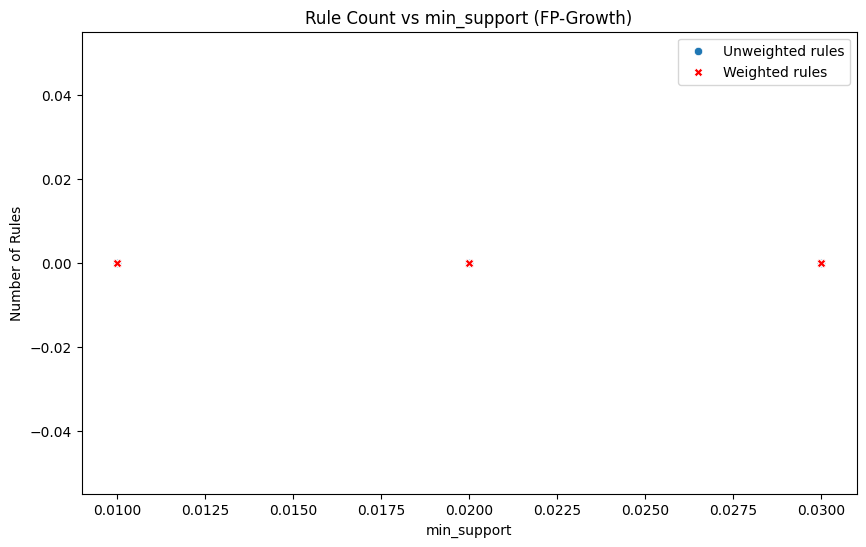

In [46]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='min_s', y='num_rules', data=df_params, label='Unweighted rules')
sns.scatterplot(x='min_s', y='num_rules_w', data=df_weighted_params, marker='X', color='red', label='Weighted rules')
plt.title('Rule Count vs min_support (FP-Growth)')
plt.xlabel('min_support')
plt.ylabel('Number of Rules')
plt.legend()
plt.show()

# Cell 9 — Top luật theo weighted_lift

In [ ]:
min_s, min_c, min_l = 0.02, 0.3, 1.0

# Loại bỏ hóa đơn trống
basket_nonempty = basket_sparse[basket_sparse.sum(axis=1) > 0]

# Tìm tập phổ biến
freq_items = fpgrowth(basket_nonempty, min_support=min_s, use_colnames=True)

# Nếu freq_items rỗng thì dừng, không gọi weighted_metrics
if freq_items.empty:
    print("Không tìm thấy tập phổ biến với min_support =", min_s)
else:
    rules = association_rules(freq_items, metric="confidence", min_threshold=min_c)
    rules = rules[rules['lift'] >= min_l]
    
    if rules.empty:
        print("Không có luật nào với min_confidence và min_lift hiện tại")
    else:
        chosen_w = weighted_metrics(rules.copy(), df_clean)
        # Hiển thị top 15 luật theo weighted_lift
        chosen_w.sort_values('weighted_lift', ascending=False).head(15)[
            ['antecedents','consequents','support','weighted_support','lift','weighted_lift']
        ]


ValueError: The input DataFrame `df` containing the frequent itemsets is empty.

# Cell 10 — Rút ra ngưỡng hợp lý

In [ ]:
# Unweighted - phổ biến
df_params.sort_values('num_rules', ascending=False).head(3)

# Weighted - giá trị/doanh thu
df_weighted_params.sort_values('num_rules_w', ascending=False).head(3)